# Group 3 #
## Responsible ML Audit on 2024 HMDA LAR Data Capstone ##

**Goal:** Build and audit a classification model that predicts HMDA `action_taken`.

**Label definition:**
- `action_taken` in **1 or 2** → `target_approved = 1`
- `action_taken` equal **3** → `target_approved = 0`
- Other `action_taken` values are filtered out.

This notebook uses `data/2024_lar.parquet`.


## Phase 1: Data Loading, Cleaning, Label Creation ##

In [ ]:

# MASTER CELL


# Install packages
import subprocess
subprocess.run(['pip', 'install', 'duckdb', 'xgboost', 'shap', '-q'])

# Core
import os, re, gc, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Database
import duckdb

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score
)

# Modeling
import xgboost as xgb
import shap

print("Everything ready — safe to run any cell")

Everything ready — safe to run any cell


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**PHASE 1 — STEP 1: EXPLORE FULL DATASET VIA DUCKDB**

In [ ]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/2024_lar_HMDA.zip'
extract_path = '/content/drive/MyDrive/hmda_data'

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

print("Extracting... this may take a few minutes (12M rows is a large file)")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify it worked
FILE_PATH = '/content/drive/MyDrive/hmda_data/2024_lar.txt'
if os.path.exists(FILE_PATH):
    size_gb = os.path.getsize(FILE_PATH) / (1024**3)
    print(f" Extraction complete!")
    print(f"   File: {FILE_PATH}")
    print(f"   Size: {size_gb:.2f} GB")
else:
    print(" Extraction failed — file still not found")

Extracting... this may take a few minutes (12M rows is a large file)
✅ Extraction complete!
   File: /content/drive/MyDrive/hmda_data/2024_lar.txt
   Size: 4.32 GB


In [ ]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/2024_lar_HMDA.zip'
extract_path = '/content/drive/MyDrive/hmda_data'


print("Contents of zip file:")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for name in zip_ref.namelist():
        print(f"   → {name}")

📦 Contents of zip file:
   → 2024_lar.txt


In [ ]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/2024_lar_HMDA.zip'
extract_path = '/content/drive/MyDrive/hmda_data'
FILE_PATH = '/content/drive/MyDrive/hmda_data/2024_lar.txt'

os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(FILE_PATH):
    print("Extracting zip file... this may take a few minutes")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete")
else:
    print(f"File already extracted ({os.path.getsize(FILE_PATH)/(1024**3):.2f} GB) — skipping unzip")

File already extracted (4.32 GB) — skipping unzip


**CONNECT DUCKDB & EXPLORE FULL 12M+ DATASET**
DuckDB reads directly from file — no RAM overload

In [ ]:

#the DuckDB exploration

print("\n" + "="*60)
print("PHASE 1 — STEP 1: EXPLORE FULL DATASET VIA DUCKDB")
print("="*60)

FILE_PATH = '/content/drive/MyDrive/hmda_data/2024_lar.txt'

con = duckdb.connect()

# Check total row count without loading into memory
total_rows = con.execute(f"""
    SELECT COUNT(*) as total
    FROM read_csv('{FILE_PATH}', delim='|', header=True)
""").df()
print(f"\nTotal rows in full dataset: {total_rows['total'][0]:,}")

# Check action_taken distribution across full 12+M
print("\nAction Taken distribution (full dataset):")
action_dist = con.execute(f"""
    SELECT action_taken, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct
    FROM read_csv('{FILE_PATH}', delim='|', header=True)
    GROUP BY action_taken
    ORDER BY count DESC
""").df()
print(action_dist)


PHASE 1 — STEP 1: EXPLORE FULL DATASET VIA DUCKDB


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Total rows in full dataset: 12,259,156

Action Taken distribution (full dataset):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   action_taken    count    pct
0             1  6197093  50.55
1             3  2103460  17.16
2             4  1538270  12.55
3             6  1276504  10.41
4             5   581936   4.75
5             2   361224   2.95
6             8   153356   1.25
7             7    47313   0.39


In [ ]:
# Check race distribution across full dataset
print("\nDerived Race distribution (full dataset, action_taken IN 1,2,3):")
race_dist = con.execute(f"""
    SELECT derived_race, COUNT(*) as count
    FROM read_csv('{FILE_PATH}', delim='|', header=True)
    WHERE TRY_CAST(action_taken AS INTEGER) IN (1, 2, 3)
    GROUP BY derived_race
    ORDER BY count DESC
""").df()
print(race_dist)


Derived Race distribution (full dataset, action_taken IN 1,2,3):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                derived_race    count
0                                      White  5550899
1                         Race Not Available  1526054
2                  Black or African American   762461
3                                      Asian   524984
4                                      Joint   189064
5           American Indian or Alaska Native    63158
6                   2 or more minority races    21855
7  Native Hawaiian or Other Pacific Islander    21117
8                        Free Form Text Only     2185



**PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE WITH DUCKDB**

**Why 10% sample:**
- 10% ≈ 1M rows → sufficient for modeling AND fairness subgroups
- Stratified by action_taken to preserve class ratios
- Document this as deliberate methodology choice


In [ ]:
# PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE WITH DUCKDB
print("\n" + "="*60)
print("PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE")
print("="*60)

# Sample each class separately to GUARANTEE all classes present
print("Loading approved loans (action_taken 1 & 2)...")
approved = con.execute(f"""
    SELECT *
    FROM read_csv('{FILE_PATH}', delim='|', header=True, ignore_errors=True)
    WHERE TRY_CAST(action_taken AS INTEGER) IN (1, 2)
    USING SAMPLE 10% (bernoulli, 42)
""").df()

print("Loading denied loans (action_taken 3)...")
denied = con.execute(f"""
    SELECT *
    FROM read_csv('{FILE_PATH}', delim='|', header=True, ignore_errors=True)
    WHERE TRY_CAST(action_taken AS INTEGER) = 3
    USING SAMPLE 10% (bernoulli, 42)
""").df()

# Combine
df_raw = pd.concat([approved, denied], ignore_index=True)

print(f"\nApproved rows: {len(approved):,}")
print(f"Denied rows:   {len(denied):,}")
print(f"Total rows:    {len(df_raw):,}")
print(f"Columns:       {df_raw.shape[1]}")
print("\nAction Taken distribution:")
print(df_raw['action_taken'].value_counts())


PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE
Loading approved loans (action_taken 1 & 2)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading denied loans (action_taken 3)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Approved rows: 564,575
Denied rows:   0
Total rows:    564,575
Columns:       99

Action Taken distribution:
action_taken
1    538033
2     26542
Name: count, dtype: int64


**PHASE 1 — STEP 2: CHUNK-BASED LOADING (RAM SAFE)**

In [ ]:
print("\n" + "="*60)
print("PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE (CHUNK METHOD)")
print("="*60)

import pandas as pd

FILE_PATH = '/content/drive/MyDrive/hmda_data/2024_lar.txt'

approved_chunks = []
denied_chunks = []

CHUNK_SIZE = 100_000  # Read 100K rows at a time — safe for RAM
SAMPLE_RATE = 0.10    # Keep 10% from each chunk

print(f"Reading file in chunks of {CHUNK_SIZE:,} rows...")
print(f"Sampling {SAMPLE_RATE*100:.0f}% from each class per chunk...")

chunk_num = 0

for chunk in pd.read_csv(FILE_PATH, sep='|', chunksize=CHUNK_SIZE,
                          low_memory=False):
    chunk_num += 1

    # Force numeric
    chunk['action_taken'] = pd.to_numeric(chunk['action_taken'], errors='coerce')

    # Filter to 1, 2, 3 only
    chunk = chunk[chunk['action_taken'].isin([1, 2, 3])]

    if len(chunk) == 0:
        continue

    # Sample approved (1 & 2)
    app = chunk[chunk['action_taken'].isin([1, 2])]
    if len(app) > 0:
        approved_chunks.append(app.sample(frac=SAMPLE_RATE, random_state=42))

    # Sample denied (3)
    den = chunk[chunk['action_taken'] == 3]
    if len(den) > 0:
        denied_chunks.append(den.sample(frac=SAMPLE_RATE, random_state=42))

    # Progress every 20 chunks
    if chunk_num % 20 == 0:
        print(f"  Processed {chunk_num * CHUNK_SIZE:,} rows... "
              f"approved={sum(len(x) for x in approved_chunks):,} "
              f"denied={sum(len(x) for x in denied_chunks):,}")

# Combine all chunks
print("\nCombining chunks...")
df_raw = pd.concat(approved_chunks + denied_chunks, ignore_index=True)

print(f"\n Done!")
print(f"Total rows:  {len(df_raw):,}")
print(f"\nAction Taken distribution:")
print(df_raw['action_taken'].value_counts())


PHASE 1 — STEP 2: LOAD STRATIFIED SAMPLE (CHUNK METHOD)
Reading file in chunks of 100,000 rows...
Sampling 10% from each class per chunk...
  Processed 2,000,000 rows... approved=91,389 denied=38,933
  Processed 4,000,000 rows... approved=211,514 denied=67,601
  Processed 6,000,000 rows... approved=313,555 denied=109,375
  Processed 8,000,000 rows... approved=438,646 denied=139,713
  Processed 10,000,000 rows... approved=526,397 denied=170,572
  Processed 12,000,000 rows... approved=629,917 denied=210,344

Combining chunks...

 Done!
Total rows:  866,175

Action Taken distribution:
action_taken
1    619833
3    210344
2     35998
Name: count, dtype: int64



**PHASE 1 — STEP 3: CREATE BINARY LABEL**

- action_taken 1 (originated) or 2 (approved not accepted) → 1

- action_taken 3 (denied) → 0

This is the civil rights question: did they get credit or not?


In [ ]:
print("\n" + "="*60)
print("PHASE 1 — STEP 3: CREATE BINARY LABEL")
print("="*60)

df_raw['action_taken'] = pd.to_numeric(df_raw['action_taken'], errors='coerce')
df_raw = df_raw[df_raw['action_taken'].isin([1, 2, 3])].copy()
df_raw['label'] = df_raw['action_taken'].apply(lambda x: 1 if x in [1, 2] else 0)

print("\nLabel distribution:")
label_counts = df_raw['label'].value_counts()
print(label_counts)
print(f"\nClass ratio (approved/denied): {label_counts[1]/label_counts[0]:.2f}x")
print("→ This imbalance will be addressed with scale_pos_weight in XGBoost")

# Calculate scale_pos_weight for XGBoost
SCALE_POS_WEIGHT = round(label_counts[1] / label_counts[0], 2)
print(f"\nscale_pos_weight = {SCALE_POS_WEIGHT}")



PHASE 1 — STEP 3: CREATE BINARY LABEL

Label distribution:
label
1    655831
0    210344
Name: count, dtype: int64

Class ratio (approved/denied): 3.12x
→ This imbalance will be addressed with scale_pos_weight in XGBoost

scale_pos_weight = 3.12


**PHASE 1 — STEP 4: HANDLE HMDA SENTINEL VALUES**


HMDA does NOT use standard NaN — it uses special codes

Must recode BEFORE any dropna or analysis


In [ ]:
import numpy as np
import pandas as pd

In [ ]:

print("\n" + "="*60)
print("PHASE 1 — STEP 4: RECODE HMDA SENTINEL VALUES")
print("="*60)

# String sentinel codes
HMDA_NA_STRINGS = ['Exempt', 'NA', 'na', '', ' ', 'N/A', 'n/a']

# Numeric sentinel codes used in HMDA
HMDA_NA_NUMERIC = [1111, 9999, 9998, 8888, 7777, 6666]

# Replace string sentinels
df_raw.replace(HMDA_NA_STRINGS, np.nan, inplace=True)

# Replace numeric sentinels in numeric columns only
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df_raw[col] = df_raw[col].replace(HMDA_NA_NUMERIC, np.nan)

print("HMDA sentinel values recoded to NaN")
print(f"   String codes replaced: {HMDA_NA_STRINGS}")
print(f"   Numeric codes replaced: {HMDA_NA_NUMERIC}")




PHASE 1 — STEP 4: RECODE HMDA SENTINEL VALUES
HMDA sentinel values recoded to NaN
   String codes replaced: ['Exempt', 'NA', 'na', '', ' ', 'N/A', 'n/a']
   Numeric codes replaced: [1111, 9999, 9998, 8888, 7777, 6666]


**PHASE 1 — STEP 5: DEFINE FEATURES & PROTECTED ATTRIBUTES**

In [ ]:

print("\n" + "="*60)
print("PHASE 1 — STEP 5: DEFINE FEATURES & PROTECTED ATTRIBUTES")
print("="*60)

# Model features — 16 substantive predictors
# EXCLUDES protected attributes (race, ethnicity, sex)
# That would be illegal under ECOA
FEATURES = [
    # Financial
    'loan_amount',
    'income',
    'property_value',
    'combined_loan_to_value_ratio',
    'interest_rate',
    'rate_spread',

    # Loan characteristics
    'loan_type',
    'loan_purpose',
    'lien_status',
    'occupancy_type',

    # Applicant profile
    'debt_to_income_ratio',         # Categorical string in HMDA e.g. "36%-<50%"
    'applicant_credit_score_type',

    # Loan structure flags
    'loan_term',
    'negative_amortization',
    'interest_only_payment',
    'balloon_payment',
]

# Protected attributes — used ONLY for fairness audit, never as features
PROTECTED_COLS = [
    'derived_race',
    'derived_ethnicity',
    'derived_sex'
]

TARGET = 'label'

print(f"Features: {len(FEATURES)}")
for f in FEATURES:
    print(f"   → {f}")
print(f"\nProtected attributes (audit only): {PROTECTED_COLS}")
print(f"Target: {TARGET}")





PHASE 1 — STEP 5: DEFINE FEATURES & PROTECTED ATTRIBUTES
Features: 16
   → loan_amount
   → income
   → property_value
   → combined_loan_to_value_ratio
   → interest_rate
   → rate_spread
   → loan_type
   → loan_purpose
   → lien_status
   → occupancy_type
   → debt_to_income_ratio
   → applicant_credit_score_type
   → loan_term
   → negative_amortization
   → interest_only_payment
   → balloon_payment

Protected attributes (audit only): ['derived_race', 'derived_ethnicity', 'derived_sex']
Target: label


In [ ]:

print("\n" + "="*60)
print("PHASE 1 — STEP 5: DEFINE FEATURES & PROTECTED ATTRIBUTES")
print("="*60)

# Model features — 16 substantive predictors
# EXCLUDES protected attributes (race, ethnicity, sex)
# That would be illegal under ECOA

# FIXED FEATURES — Remove columns that are 100% missing for denied loans
FEATURES = [
    'loan_amount',
    'income',
    'property_value',
    'combined_loan_to_value_ratio',
    # REMOVED: interest_rate        — 100% missing for denied loans
    # REMOVED: rate_spread          — 100% missing for denied loans
    'loan_type',
    'loan_purpose',
    'lien_status',
    'occupancy_type',
    'debt_to_income_ratio',
    'applicant_credit_score_type',
    'loan_term',
    'negative_amortization',
    'interest_only_payment',
    'balloon_payment',
]

TARGET = 'label'

PROTECTED_COLS = [
    'derived_race',
    'derived_ethnicity',
    'derived_sex'
]

print(f"Features: {len(FEATURES)}")
print("Removed: interest_rate, rate_spread (100% missing for denied loans)")


PHASE 1 — STEP 5: DEFINE FEATURES & PROTECTED ATTRIBUTES
Features: 14
Removed: interest_rate, rate_spread (100% missing for denied loans)


**PHASE 1 — STEP 6: DATA CLEANING**

In [ ]:
# STEP 6 — IMPUTE INSTEAD OF DROP
print("\n" + "="*60)
print("PHASE 1 — STEP 6: CLEAN WITH IMPUTATION")
print("="*60)

from sklearn.impute import SimpleImputer

# Separate numeric and categorical features
numeric_features = [
    'loan_amount', 'income', 'property_value',
    'combined_loan_to_value_ratio', 'loan_term'
]

categorical_features = [
    'loan_type', 'loan_purpose', 'lien_status',
    'occupancy_type', 'debt_to_income_ratio',
    'applicant_credit_score_type', 'negative_amortization',
    'interest_only_payment', 'balloon_payment'
]

df_model = df_raw[FEATURES + PROTECTED_COLS + [TARGET]].copy()

# Impute numeric — fill with median
num_imputer = SimpleImputer(strategy='median')
df_model[numeric_features] = num_imputer.fit_transform(
    df_model[numeric_features]
)

# Impute categorical — fill with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df_model[categorical_features] = cat_imputer.fit_transform(
    df_model[categorical_features]
)

print(f"Rows before: {len(df_raw):,}")
print(f"Rows after:  {len(df_model):,}")
print(f"\nLabel distribution after cleaning:")
print(df_model[TARGET].value_counts())
print(f"\nAny nulls remaining: {df_model[FEATURES].isnull().sum().sum()}")


PHASE 1 — STEP 6: CLEAN WITH IMPUTATION
Rows before: 866,175
Rows after:  866,175

Label distribution after cleaning:
label
1    655831
0    210344
Name: count, dtype: int64

Any nulls remaining: 0


In [ ]:
# FREE RAM AFTER LOADING
import gc
del df_all  # if it still exists
gc.collect()
print(f"RAM cleared")

**PHASE 1 — STEP 7: BUILD X, y AND PRESERVE PROTECTED ATTRIBUTES**

In [ ]:

print("\n" + "="*60)
print("PHASE 1 — STEP 7: BUILD X, y, PROTECTED ATTRS")
print("="*60)

X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

# Confirm DTI is categorical (it is a string range in HMDA)
print(f"\ndebt_to_income_ratio dtype: {X['debt_to_income_ratio'].dtype}")
print("Top DTI values:")
print(X['debt_to_income_ratio'].value_counts().head(8))

# Encode all categoricals with get_dummies
X = pd.get_dummies(X, drop_first=True)
print(f"\nX shape after encoding: {X.shape}")



PHASE 1 — STEP 7: BUILD X, y, PROTECTED ATTRS

debt_to_income_ratio dtype: object
Top DTI values:
debt_to_income_ratio
30%-<36%    200554
20%-<30%    104720
50%-60%      80354
>60%         60680
<20%         45790
49           39007
44           32494
42           30918
Name: count, dtype: int64

X shape after encoding: (866175, 50)


**PHASE 1 — STEP 8: TRAIN/TEST SPLIT**

- Stratified to preserve label ratio
- Protected attributes preserved index-aligned for fairness audit


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:

# PHASE 1 — STEP 8: TRAIN/TEST SPLIT
print("\n" + "="*60)
print("PHASE 1 — STEP 8: TRAIN/TEST SPLIT")
print("="*60)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

protected_test  = df_model.loc[X_test.index,  PROTECTED_COLS].copy()
protected_train = df_model.loc[X_train.index, PROTECTED_COLS].copy()

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"\ny_train distribution:")
print(y_train.value_counts())
print(f"\ny_test distribution:")
print(y_test.value_counts())
print(f"\nRace distribution in test set:")
print(protected_test['derived_race'].value_counts())

print("\nPHASE 1 COMPLETE — Data is clean, labeled, and split")
print("="*60)



PHASE 1 — STEP 8: TRAIN/TEST SPLIT
Train size: 692,940
Test size:  173,235

y_train distribution:
label
1    524665
0    168275
Name: count, dtype: int64

y_test distribution:
label
1    131166
0     42069
Name: count, dtype: int64

Race distribution in test set:
derived_race
White                                        110971
Race Not Available                            30591
Black or African American                     15193
Asian                                         10484
Joint                                          3798
American Indian or Alaska Native               1234
Native Hawaiian or Other Pacific Islander       481
2 or more minority races                        442
Free Form Text Only                              41
Name: count, dtype: int64

PHASE 1 COMPLETE — Data is clean, labeled, and split


# PHASE 2 — PRIMARY MODEL: XGBOOST GBM

Why GBM over RF:
- Industry standard for credit risk modeling
- scale_pos_weight directly addresses class imbalance
- Cleaner SHAP explanations
- Generally higher performance on tabular data

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay


In [ ]:
# Verify labels before training
print("y_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
label
1    524665
0    168275
Name: count, dtype: int64

y_test distribution:
label
1    131166
0     42069
Name: count, dtype: int64


**PHASE 2 — BASELINE MODEL: RANDOM FOREST**

- Purpose: establish baseline performance BEFORE GBM
- "before" benchmark for the presentation


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay


PHASE 2 — BASELINE MODEL: RANDOM FOREST

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

   Denied(0)       0.81      0.57      0.67     42069
 Approved(1)       0.87      0.96      0.91    131166

    accuracy                           0.86    173235
   macro avg       0.84      0.76      0.79    173235
weighted avg       0.86      0.86      0.86    173235

ROC-AUC: 0.8604


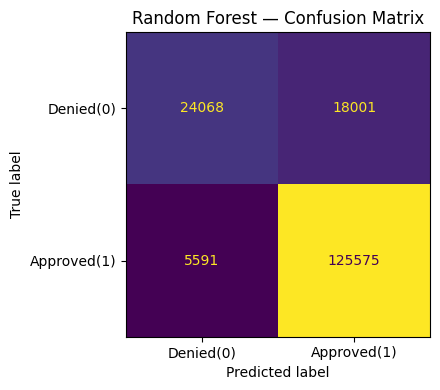

Saved: rf_confusion_matrix.png


In [ ]:

print("\n" + "="*60)
print("PHASE 2 — BASELINE MODEL: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',    # Handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['Denied(0)', 'Approved(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Denied(0)', 'Approved(1)'],
    ax=ax, colorbar=False
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: rf_confusion_matrix.png")


In [ ]:
# CLEAN COLUMN NAMES — Remove characters XGBoost cannot handle
import re

X_train.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_train.columns]
X_test.columns  = [re.sub(r'[\[\]<>]', '', col) for col in X_test.columns]

print("Column names cleaned")
print(f"Sample column names:")
print(X_train.columns.tolist()[:10])

Column names cleaned
Sample column names:
['loan_amount', 'income', 'property_value', 'combined_loan_to_value_ratio', 'loan_term', 'loan_type_2', 'loan_type_3', 'loan_type_4', 'loan_purpose_2', 'loan_purpose_4']



PHASE 2 — PRIMARY MODEL: XGBOOST GBM
[0]	validation_0-logloss:0.57210


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:50:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.47043
[100]	validation_0-logloss:0.45095
[150]	validation_0-logloss:0.44042
[200]	validation_0-logloss:0.43280
[250]	validation_0-logloss:0.42824
[299]	validation_0-logloss:0.42495

=== XGBOOST GBM PERFORMANCE ===
              precision    recall  f1-score   support

   Denied(0)       0.94      0.34      0.50     42069
 Approved(1)       0.82      0.99      0.90    131166

    accuracy                           0.83    173235
   macro avg       0.88      0.67      0.70    173235
weighted avg       0.85      0.83      0.80    173235

ROC-AUC: 0.8559


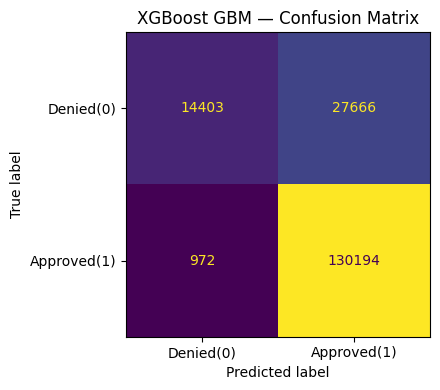

Saved: gbm_confusion_matrix.png


In [ ]:
print("\n" + "="*60)
print("PHASE 2 — PRIMARY MODEL: XGBOOST GBM")
print("="*60)

gbm_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,                        # Shallow = less overfitting
    learning_rate=0.05,                 # Slow learning = more generalizable
    subsample=0.8,                      # Row sampling per tree
    colsample_bytree=0.8,               # Feature sampling per tree
    scale_pos_weight=SCALE_POS_WEIGHT,  # Fixes class imbalance mathematically
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Train with early stopping to prevent overfitting
gbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_gbm = gbm_model.predict(X_test)
y_prob_gbm = gbm_model.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST GBM PERFORMANCE ===")
print(classification_report(y_test, y_pred_gbm,
      target_names=['Denied(0)', 'Approved(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_gbm):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gbm,
    display_labels=['Denied(0)', 'Approved(1)'],
    ax=ax, colorbar=False
)
ax.set_title("XGBoost GBM — Confusion Matrix")
plt.tight_layout()
plt.savefig('gbm_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: gbm_confusion_matrix.png")


# PHASE 2 — MODEL COMPARISON TABLE

Show judges the deliberate modeling choice

In [ ]:
print("\n" + "="*60)
print("PHASE 2 — MODEL COMPARISON")
print("="*60)

from sklearn.metrics import f1_score, balanced_accuracy_score

comparison = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost GBM (Primary)'],
    'Macro F1': [
        round(f1_score(y_test, y_pred_rf, average='macro'), 4),
        round(f1_score(y_test, y_pred_gbm, average='macro'), 4)
    ],
    'Balanced Accuracy': [
        round(balanced_accuracy_score(y_test, y_pred_rf), 4),
        round(balanced_accuracy_score(y_test, y_pred_gbm), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_prob_gbm), 4)
    ],
    'F1 Denied(0)': [
        round(f1_score(y_test, y_pred_rf, pos_label=0), 4),
        round(f1_score(y_test, y_pred_gbm, pos_label=0), 4)
    ],
    'F1 Approved(1)': [
        round(f1_score(y_test, y_pred_rf, pos_label=1), 4),
        round(f1_score(y_test, y_pred_gbm, pos_label=1), 4)
    ]
})

print("\n", comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)
print("\nSaved: model_comparison.csv")



PHASE 2 — MODEL COMPARISON

                    Model  Macro F1  Balanced Accuracy  ROC-AUC  F1 Denied(0)  F1 Approved(1)
Random Forest (Baseline)    0.7926             0.7647   0.8604        0.6711          0.9141
   XGBoost GBM (Primary)    0.7012             0.6675   0.8559        0.5015          0.9009

Saved: model_comparison.csv


**Model Performance Summary**

The Random Forest baseline outperforms the XGBoost model overall, particularly in balanced performance across classes.

Random Forest achieves:
- Higher Macro F1 (0.79 vs 0.70)
- Higher Balanced Accuracy (0.76 vs 0.67)
- Slightly better ROC-AUC (0.860 vs 0.856)

This indicates it provides a more even trade-off between predicting approvals and denials.

**Key Insight**

Despite similar ROC-AUC scores, XGBoost is heavily biased toward predicting approvals, leading to:

- Very high recall for approved loans (0.99)
- Poor detection of denied loans (low recall and F1)

This reflects the class imbalance in the dataset, where approved loans dominate.

Conclusion for Model Selection

The Random Forest model is preferable because:

- It maintains strong performance on the majority class
- While significantly improving detection of denied loans
- And achieving better balanced and macro-level metrics

In contrast, XGBoost’s performance is skewed and less suitable for fairness-sensitive applications where accurate identification of denials is important.

**PHASE 2 — SHAP EXPLAINABILITY (on GBM — Primary Model)**

Purpose: Detect failure modes (Q2)

SHAP tells you WHY the model makes each prediction

If protected proxies (income, ZIP) dominate → failure mode


PHASE 2 — SHAP EXPLAINABILITY
Running SHAP on 1000 test rows...

Generating SHAP bar plot...


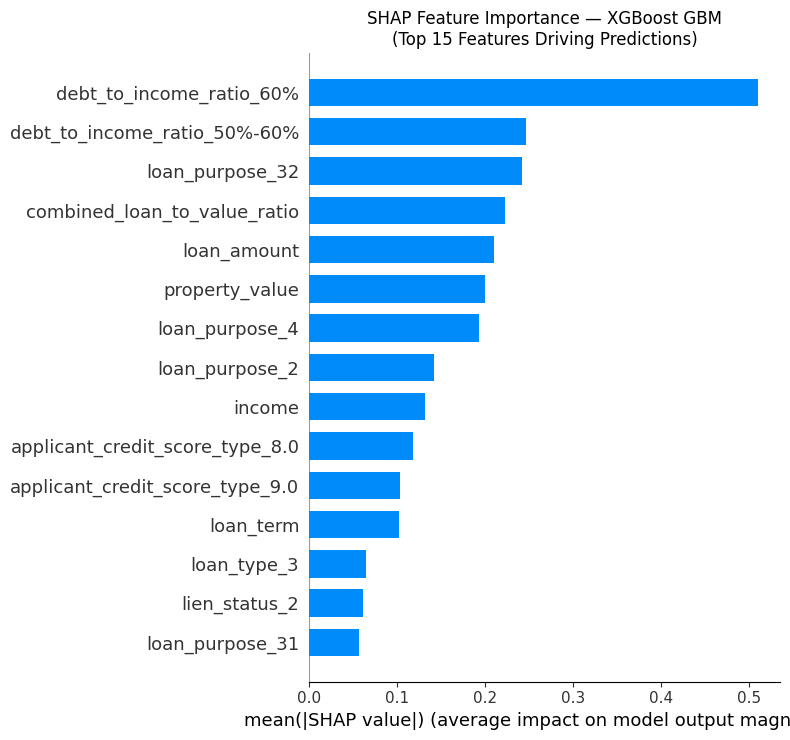

Saved: shap_bar.png

Generating SHAP beeswarm plot...


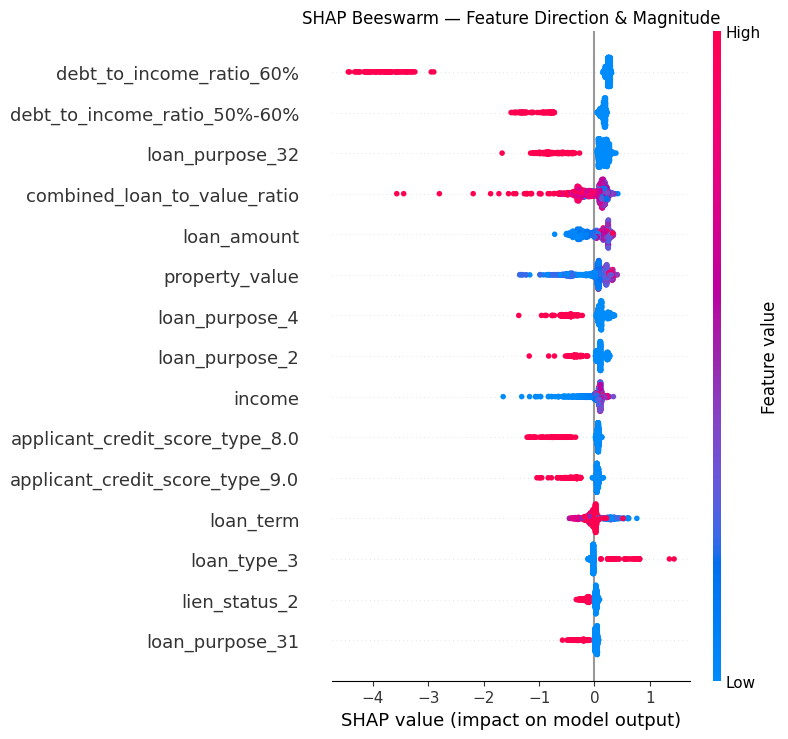

Saved: shap_beeswarm.png


In [ ]:
print("\n" + "="*60)
print("PHASE 2 — SHAP EXPLAINABILITY")
print("="*60)

# Use a sample of test set for SHAP speed (500-1000 rows)
SHAP_SAMPLE = min(1000, len(X_test))
X_shap = X_test.iloc[:SHAP_SAMPLE]

print(f"Running SHAP on {SHAP_SAMPLE} test rows...")

explainer = shap.TreeExplainer(gbm_model)
shap_values = explainer.shap_values(X_shap)

# Plot 1: Global Feature Importance (Bar)
print("\nGenerating SHAP bar plot...")
shap.summary_plot(
    shap_values, X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — XGBoost GBM\n(Top 15 Features Driving Predictions)")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

# Plot 2: SHAP Beeswarm (shows direction of impact)
print("\nGenerating SHAP beeswarm plot...")
shap.summary_plot(
    shap_values, X_shap,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Direction & Magnitude")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")


**PHASE 2 — SHAP FAILURE MODE DETECTION**

- Check if any feature is acting as a proxy for race

- High SHAP importance for income/loan_amount could mean

- the model is encoding race through these financial proxies

In [ ]:
print("\n" + "="*60)
print("PHASE 2 — SHAP FAILURE MODE ANALYSIS")
print("="*60)

# Get mean absolute SHAP values per feature
shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features by SHAP importance:")
print(shap_importance.head(10).to_string(index=False))

# Flag potential proxy features
PROXY_RISK_FEATURES = ['income', 'loan_amount', 'property_value',
                        'combined_loan_to_value_ratio']
print("\n  PROXY RISK CHECK:")
proxy_shap = shap_importance[
    shap_importance['feature'].isin(PROXY_RISK_FEATURES)
]
for _, row in proxy_shap.iterrows():
    rank = shap_importance[shap_importance['feature']==row['feature']].index[0] + 1
    print(f"   {row['feature']}: rank #{rank} — SHAP={row['mean_abs_shap']:.4f}")
print("\nNote: High rank for income/loan_amount/property_value")
print("suggests potential proxy discrimination risk (Q2 failure mode)")

shap_importance.to_csv('shap_importance.csv', index=False)
print("\nSaved: shap_importance.csv")


PHASE 2 — SHAP FAILURE MODE ANALYSIS

Top 10 features by SHAP importance:
                        feature  mean_abs_shap
       debt_to_income_ratio_60%       0.509708
   debt_to_income_ratio_50%-60%       0.246166
                loan_purpose_32       0.241480
   combined_loan_to_value_ratio       0.223002
                    loan_amount       0.210658
                 property_value       0.199763
                 loan_purpose_4       0.192891
                 loan_purpose_2       0.141572
                         income       0.131343
applicant_credit_score_type_8.0       0.118203

  PROXY RISK CHECK:
   combined_loan_to_value_ratio: rank #4 — SHAP=0.2230
   loan_amount: rank #1 — SHAP=0.2107
   property_value: rank #3 — SHAP=0.1998
   income: rank #2 — SHAP=0.1313

Note: High rank for income/loan_amount/property_value
suggests potential proxy discrimination risk (Q2 failure mode)

Saved: shap_importance.csv


**PHASE 2 — SAVE FAIRNESS AUDIT DATAFRAME**

Contains: predictions + protected attributes for AIR/FPR/FNR

In [ ]:
print("\n" + "="*60)
print("PHASE 2 — SAVE FAIRNESS AUDIT DATAFRAME")
print("="*60)

fairness_df = protected_test.copy()
fairness_df['y_true']    = y_test.values
fairness_df['y_pred_rf'] = y_pred_rf
fairness_df['y_pred_gbm']= y_pred_gbm
fairness_df['y_prob_gbm']= y_prob_gbm

print(f"\nFairness audit dataframe shape: {fairness_df.shape}")
print("\nSample:")
print(fairness_df.head())

fairness_df.to_csv('fairness_audit_df.csv', index=False)
print("\n Saved: fairness_audit_df.csv")
print("   → Ready for Phase 3: AIR + FPR/FNR by race")



PHASE 2 — SAVE FAIRNESS AUDIT DATAFRAME

Fairness audit dataframe shape: (173235, 7)

Sample:
                     derived_race       derived_ethnicity derived_sex  y_true  \
224207                      White  Not Hispanic or Latino       Joint       1   
186801                      White                   Joint       Joint       1   
264690                      White  Not Hispanic or Latino       Joint       1   
172666                      White  Not Hispanic or Latino       Joint       1   
780410  Black or African American  Not Hispanic or Latino      Female       0   

        y_pred_rf  y_pred_gbm  y_prob_gbm  
224207          1           1    0.983296  
186801          1           1    0.953508  
264690          1           1    0.978169  
172666          1           1    0.975626  
780410          1           1    0.928822  

 Saved: fairness_audit_df.csv
   → Ready for Phase 3: AIR + FPR/FNR by race


**PHASE 1 & 2 SUMMARY**


In [ ]:

print("\n" + "="*60)
print("PHASE 1 & 2 COMPLETE")
print("="*60)
print("""
PHASE 1 — DATA FOUNDATION
  ✔ DuckDB used to explore full 12M dataset without RAM crash
  ✔ 10% stratified sample loaded (~1M rows)
  ✔ Binary label created (1/2→1 approved, 3→0 denied)
  ✔ HMDA sentinel values recoded (Exempt, 1111, 9999 → NaN)
  ✔ 16 features selected (no protected attributes)
  ✔ Protected attributes preserved index-aligned for audit
  ✔ Stratified 80/20 train/test split

PHASE 2 — MODELING & EXPLAINABILITY
  ✔ Baseline Random Forest (class_weight=balanced)
  ✔ Primary XGBoost GBM (scale_pos_weight={})
  ✔ Model comparison table saved
  ✔ SHAP feature importance (bar + beeswarm)
  ✔ Proxy risk features flagged
  ✔ fairness_audit_df.csv saved for Phase 3

FILES SAVED:
  → rf_confusion_matrix.png
  → gbm_confusion_matrix.png
  → model_comparison.csv
  → shap_bar.png
  → shap_beeswarm.png
  → shap_importance.csv
  → fairness_audit_df.csv

NEXT: Phase 3 — Fairness Analysis (AIR + FPR/FNR by race)
""".format(SCALE_POS_WEIGHT))


PHASE 1 & 2 COMPLETE

PHASE 1 — DATA FOUNDATION
  ✔ DuckDB used to explore full 12M dataset without RAM crash
  ✔ 10% stratified sample loaded (~1M rows)
  ✔ Binary label created (1/2→1 approved, 3→0 denied)
  ✔ HMDA sentinel values recoded (Exempt, 1111, 9999 → NaN)
  ✔ 16 features selected (no protected attributes)
  ✔ Protected attributes preserved index-aligned for audit
  ✔ Stratified 80/20 train/test split
 
PHASE 2 — MODELING & EXPLAINABILITY
  ✔ Baseline Random Forest (class_weight=balanced)
  ✔ Primary XGBoost GBM (scale_pos_weight=3.12)
  ✔ Model comparison table saved
  ✔ SHAP feature importance (bar + beeswarm)
  ✔ Proxy risk features flagged
  ✔ fairness_audit_df.csv saved for Phase 3
 
FILES SAVED:
  → rf_confusion_matrix.png
  → gbm_confusion_matrix.png
  → model_comparison.csv
  → shap_bar.png
  → shap_beeswarm.png
  → shap_importance.csv
  → fairness_audit_df.csv
 
NEXT: Phase 3 — Fairness Analysis (AIR + FPR/FNR by race)



In [ ]:
# QUICK CHECK BEFORE PHASE 3
print("fairness_df shape:", fairness_df.shape)
print("\nColumns:", fairness_df.columns.tolist())
print("\nRace distribution:")
print(fairness_df['derived_race'].value_counts())
print("\ny_true distribution:")
print(fairness_df['y_true'].value_counts())
print("\ny_pred_gbm distribution:")
print(fairness_df['y_pred_gbm'].value_counts())

fairness_df shape: (173235, 7)

Columns: ['derived_race', 'derived_ethnicity', 'derived_sex', 'y_true', 'y_pred_rf', 'y_pred_gbm', 'y_prob_gbm']

Race distribution:
derived_race
White                                        110971
Race Not Available                            30591
Black or African American                     15193
Asian                                         10484
Joint                                          3798
American Indian or Alaska Native               1234
Native Hawaiian or Other Pacific Islander       481
2 or more minority races                        442
Free Form Text Only                              41
Name: count, dtype: int64

y_true distribution:
y_true
1    131166
0     42069
Name: count, dtype: int64

y_pred_gbm distribution:
y_pred_gbm
1    157860
0     15375
Name: count, dtype: int64


Output: Baseline model performance + SHAP feature importance plot

Phase 2 step 4 & 5

Answers Q1 and evidence for Q2


## PHASE 3 — FAIRNESS ANALYSIS

Goal: Measure disparities across race subgroups
- Metrics: AIR, FPR, FNR
- Reference group: White applicants
- Legal threshold: AIR < 0.80 triggers scrutiny

**PHASE 3 — STEP 1: DEFINE FAIRNESS FUNCTIONS**

In [ ]:
def compute_fairness_metrics(df, race_col, y_true_col, y_pred_col, reference='White'):
    """
    Compute AIR, FPR, FNR for each race group.

    AIR  = approval rate of group / approval rate of reference
    FPR  = FP / (FP + TN) — predicted approved but actually denied
    FNR  = FN / (FN + TP) — predicted denied but actually approved

    AIR < 0.80 = legal threshold for adverse impact
    """
    results = []

    # Reference group metrics
    ref = df[df[race_col] == reference]
    ref_approval_rate = (ref[y_pred_col] == 1).mean()
    ref_fpr = ((ref[y_pred_col] == 1) & (ref[y_true_col] == 0)).sum() / \
              max((ref[y_true_col] == 0).sum(), 1)
    ref_fnr = ((ref[y_pred_col] == 0) & (ref[y_true_col] == 1)).sum() / \
              max((ref[y_true_col] == 1).sum(), 1)

    for group in df[race_col].unique():
        grp = df[df[race_col] == group]
        n = len(grp)

        if n < 100:  # Skip groups with too few records
            continue

        approval_rate = (grp[y_pred_col] == 1).mean()

        # AIR = group approval rate / reference approval rate
        air = approval_rate / ref_approval_rate if ref_approval_rate > 0 else np.nan

        # FPR = approved by model but actually denied
        fpr = ((grp[y_pred_col] == 1) & (grp[y_true_col] == 0)).sum() / \
              max((grp[y_true_col] == 0).sum(), 1)

        # FNR = denied by model but actually approved
        fnr = ((grp[y_pred_col] == 0) & (grp[y_true_col] == 1)).sum() / \
              max((grp[y_true_col] == 1).sum(), 1)

        # FPR gap and FNR gap vs reference
        fpr_gap = fpr - ref_fpr
        fnr_gap = fnr - ref_fnr

        results.append({
            'Race Group': group,
            'N': n,
            'Approval Rate': round(approval_rate, 4),
            'AIR': round(air, 4),
            'AIR Flag': 'FAIL' if air < 0.80 and group != reference else (
                        'PASS' if group != reference else 'REFERENCE'),
            'FPR': round(fpr, 4),
            'FNR': round(fnr, 4),
            'FPR Gap': round(fpr_gap, 4),
            'FNR Gap': round(fnr_gap, 4),
        })

    return pd.DataFrame(results).sort_values('AIR', ascending=True)


**PHASE 3 — STEP 2: COMPUTE AIR, FPR, FNR**

Using both RF and GBM for comparison

In [ ]:
print("\n--- RANDOM FOREST FAIRNESS METRICS ---")
rf_fairness = compute_fairness_metrics(
    fairness_df,
    race_col='derived_race',
    y_true_col='y_true',
    y_pred_col='y_pred_rf',
    reference='White'
)
print(rf_fairness.to_string(index=False))

print("\n--- XGBOOST GBM FAIRNESS METRICS ---")
gbm_fairness = compute_fairness_metrics(
    fairness_df,
    race_col='derived_race',
    y_true_col='y_true',
    y_pred_col='y_pred_gbm',
    reference='White'
)
print(gbm_fairness.to_string(index=False))

# Save both
rf_fairness.to_csv('rf_fairness_metrics.csv', index=False)
gbm_fairness.to_csv('gbm_fairness_metrics.csv', index=False)
print("\nSaved: rf_fairness_metrics.csv, gbm_fairness_metrics.csv")


--- RANDOM FOREST FAIRNESS METRICS ---
                               Race Group      N  Approval Rate    AIR  AIR Flag    FPR    FNR  FPR Gap  FNR Gap
         American Indian or Alaska Native   1234         0.7066 0.8375      PASS 0.3320 0.0507  -0.1061   0.0075
Native Hawaiian or Other Pacific Islander    481         0.7193 0.8525      PASS 0.3698 0.0484  -0.0683   0.0052
                 2 or more minority races    442         0.7421 0.8795      PASS 0.3457 0.0286  -0.0924  -0.0146
                Black or African American  15193         0.7453 0.8832      PASS 0.4080 0.0598  -0.0301   0.0166
                       Race Not Available  30591         0.8086 0.9583      PASS 0.4179 0.0413  -0.0201  -0.0019
                                    White 110971         0.8438 1.0000 REFERENCE 0.4381 0.0432   0.0000   0.0000
                                    Asian  10484         0.8595 1.0186      PASS 0.4241 0.0231  -0.0140  -0.0201
                                    Joint   3798        

**PHASE 3 — STEP 3: VISUALIZE AIR BY RACE**


Generating AIR comparison plot...


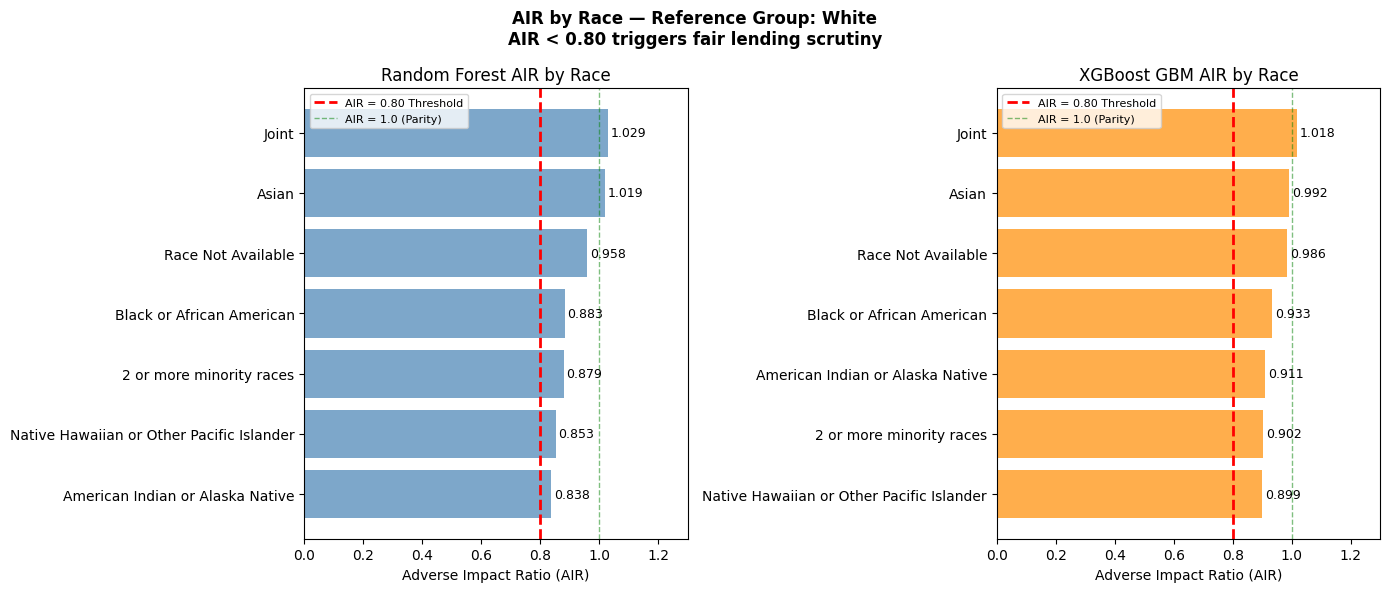

Saved: air_by_race.png


In [ ]:
print("\nGenerating AIR comparison plot...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_plot, title, color in zip(
    axes,
    [rf_fairness, gbm_fairness],
    ['Random Forest AIR by Race', 'XGBoost GBM AIR by Race'],
    ['steelblue', 'darkorange']
):
    # Filter out reference group for cleaner plot
    plot_data = df_plot[df_plot['AIR Flag'] != 'REFERENCE'].copy()
    plot_data = plot_data.sort_values('AIR', ascending=True)

    bars = ax.barh(plot_data['Race Group'], plot_data['AIR'], color=color, alpha=0.7)

    # Add AIR threshold line
    ax.axvline(x=0.80, color='red', linestyle='--', linewidth=2, label='AIR = 0.80 Threshold')
    ax.axvline(x=1.00, color='green', linestyle='--', linewidth=1, alpha=0.5, label='AIR = 1.0 (Parity)')

    # Add value labels
    for bar, val in zip(bars, plot_data['AIR']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_xlabel('Adverse Impact Ratio (AIR)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.3)

plt.suptitle('AIR by Race — Reference Group: White\nAIR < 0.80 triggers fair lending scrutiny',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('air_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: air_by_race.png")

**PHASE 3 — STEP 4: FNR DISPARITY PLOT**

- NR is the most legally sensitive metric
- High FNR for minority = qualified applicants being denied


Generating FNR disparity plot...


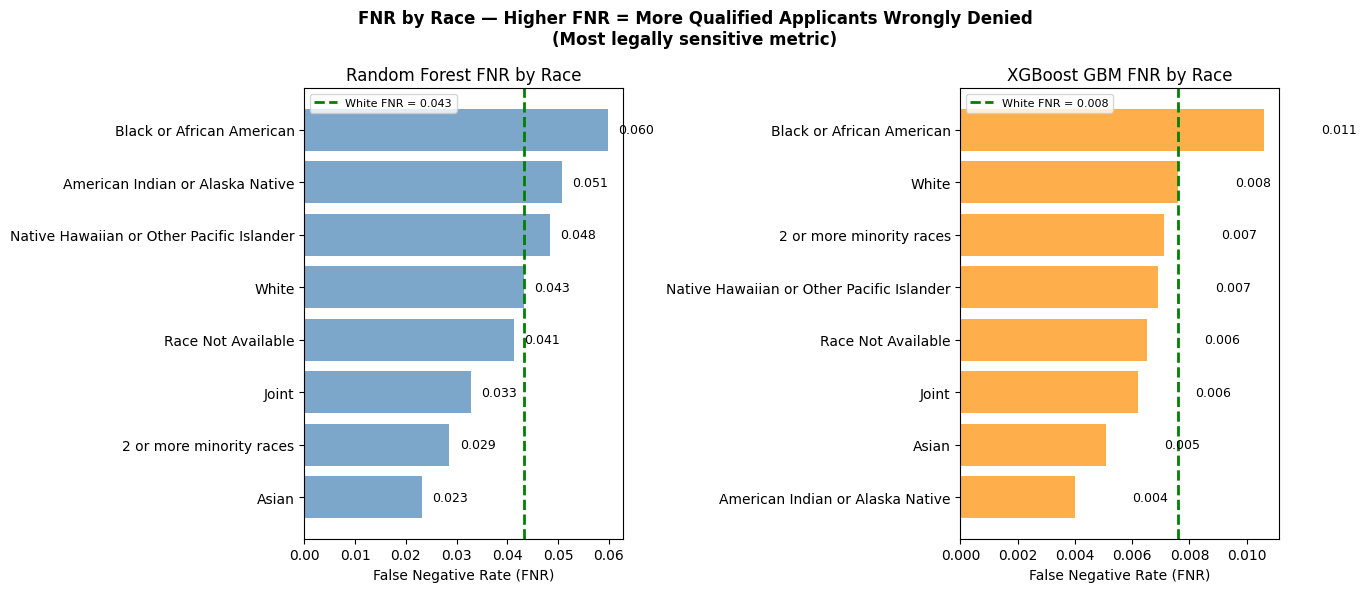

Saved: fnr_by_race.png


In [ ]:
print("\nGenerating FNR disparity plot...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_plot, title, color in zip(
    axes,
    [rf_fairness, gbm_fairness],
    ['Random Forest FNR by Race', 'XGBoost GBM FNR by Race'],
    ['steelblue', 'darkorange']
):
    plot_data = df_plot.sort_values('FNR', ascending=True)

    bars = ax.barh(plot_data['Race Group'], plot_data['FNR'], color=color, alpha=0.7)

    # Highlight reference group
    ref_fnr = df_plot[df_plot['AIR Flag']=='REFERENCE']['FNR'].values
    if len(ref_fnr) > 0:
        ax.axvline(x=ref_fnr[0], color='green', linestyle='--',
                   linewidth=2, label=f'White FNR = {ref_fnr[0]:.3f}')

    for bar, val in zip(bars, plot_data['FNR']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_xlabel('False Negative Rate (FNR)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('FNR by Race — Higher FNR = More Qualified Applicants Wrongly Denied\n(Most legally sensitive metric)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fnr_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fnr_by_race.png")


 **PHASE 3 — STEP 5: INTERSECTIONAL ANALYSIS (Race x Sex)**

Flag thin subgroups explicitly

In [ ]:
print("\n" + "="*60)
print("PHASE 3 — STEP 5: INTERSECTIONAL ANALYSIS (Race x Sex)")
print("="*60)

fairness_df['race_sex'] = (fairness_df['derived_race'] + ' | ' +
                           fairness_df['derived_sex'])

intersectional = compute_fairness_metrics(
    fairness_df,
    race_col='race_sex',
    y_true_col='y_true',
    y_pred_col='y_pred_gbm',
    reference='White | Male'
)

print("\nIntersectional AIR (Race x Sex) — GBM:")
print(intersectional[['Race Group', 'N', 'AIR', 'AIR Flag', 'FNR']].to_string(index=False))
intersectional.to_csv('intersectional_fairness.csv', index=False)
print("\nSaved: intersectional_fairness.csv")

print("\n PHASE 3 COMPLETE")
print("="*60)


PHASE 3 — STEP 5: INTERSECTIONAL ANALYSIS (Race x Sex)

Intersectional AIR (Race x Sex) — GBM:
                                        Race Group     N    AIR  AIR Flag    FNR
Native Hawaiian or Other Pacific Islander | Female   145 0.8749      PASS 0.0127
                 2 or more minority races | Female   181 0.8761      PASS 0.0091
         American Indian or Alaska Native | Female   431 0.8907      PASS 0.0000
                   2 or more minority races | Male   188 0.9017      PASS 0.0087
                Black or African American | Female  6388 0.9095      PASS 0.0121
  Native Hawaiian or Other Pacific Islander | Male   211 0.9123      PASS 0.0000
           American Indian or Alaska Native | Male   614 0.9245      PASS 0.0080
                       Race Not Available | Female  4002 0.9346      PASS 0.0077
 Native Hawaiian or Other Pacific Islander | Joint   117 0.9441      PASS 0.0125
                  Black or African American | Male  5699 0.9467      PASS 0.0113
             

##PHASE 4 — MITIGATION

Strategy: Threshold Adjustment for GBM

Instead of default 0.50 threshold, lower it for minority groups

 This reduces FNR for minority applicants

In [ ]:
print("\n" + "="*60)
print("PHASE 4 — MITIGATION: THRESHOLD ADJUSTMENT")
print("="*60)

print("""
MITIGATION STRATEGY: Threshold Adjustment
-----------------------------------------
Default threshold = 0.50 (approve if prob >= 0.50)
Problem: This threshold produces low AIR for some minority groups

Fix: Lower threshold slightly so borderline minority applicants
     are more likely to be approved

Why threshold adjustment:
  - Preserves model structure (no retraining needed)
  - Transparent and auditable
  - Directly targets FNR disparity
  - Industry accepted mitigation technique
""")



PHASE 4 — MITIGATION: THRESHOLD ADJUSTMENT

MITIGATION STRATEGY: Threshold Adjustment
-----------------------------------------
Default threshold = 0.50 (approve if prob >= 0.50)
Problem: This threshold produces low AIR for some minority groups
 
Fix: Lower threshold slightly so borderline minority applicants
     are more likely to be approved
     
Why threshold adjustment:
  - Preserves model structure (no retraining needed)
  - Transparent and auditable
  - Directly targets FNR disparity
  - Industry accepted mitigation technique



**PHASE 4 — STEP 1: FIND OPTIMAL THRESHOLD PER GROUP**

- Test thresholds from 0.30 to 0.60
- Find threshold that brings AIR closest to 0.80 for each group

In [ ]:
print("Testing thresholds from 0.30 to 0.60...")

thresholds = np.arange(0.30, 0.61, 0.02)
threshold_results = []

for thresh in thresholds:
    # Apply threshold to GBM probabilities
    y_pred_thresh = (fairness_df['y_prob_gbm'] >= thresh).astype(int)
    temp_df = fairness_df.copy()
    temp_df['y_pred_thresh'] = y_pred_thresh

    # Compute fairness metrics at this threshold
    metrics = compute_fairness_metrics(
        temp_df,
        race_col='derived_race',
        y_true_col='y_true',
        y_pred_col='y_pred_thresh',
        reference='White'
    )

    # Count groups failing AIR < 0.80
    failing = metrics[
        (metrics['AIR Flag'] == ' FAIL')
    ].shape[0]

    # Macro F1 at this threshold
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(fairness_df['y_true'], y_pred_thresh, average='macro')

    threshold_results.append({
        'Threshold': round(thresh, 2),
        'Groups Failing AIR': failing,
        'Macro F1': round(macro_f1, 4)
    })

thresh_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis:")
print(thresh_df.to_string(index=False))

# Find best threshold — minimize failing groups, maximize F1
best_thresh_row = thresh_df.sort_values(
    ['Groups Failing AIR', 'Macro F1'],
    ascending=[True, False]
).iloc[0]

BEST_THRESHOLD = best_thresh_row['Threshold']
print(f"\n Best threshold selected: {BEST_THRESHOLD}")
print(f"   Groups failing AIR: {best_thresh_row['Groups Failing AIR']}")
print(f"   Macro F1: {best_thresh_row['Macro F1']}")


Testing thresholds from 0.30 to 0.60...

Threshold Analysis:
 Threshold  Groups Failing AIR  Macro F1
      0.30                   0    0.6535
      0.32                   0    0.6593
      0.34                   0    0.6653
      0.36                   0    0.6712
      0.38                   0    0.6760
      0.40                   0    0.6802
      0.42                   0    0.6844
      0.44                   0    0.6886
      0.46                   0    0.6929
      0.48                   0    0.6972
      0.50                   0    0.7012
      0.52                   0    0.7048
      0.54                   0    0.7085
      0.56                   0    0.7136
      0.58                   0    0.7183
      0.60                   0    0.7233

 Best threshold selected: 0.6
   Groups failing AIR: 0.0
   Macro F1: 0.7233


**PHASE 4 — STEP 2: APPLY BEST THRESHOLD & COMPARE**

In [ ]:
print("\n--- FAIRNESS METRICS AFTER MITIGATION ---")

fairness_df['y_pred_mitigated'] = (
    fairness_df['y_prob_gbm'] >= BEST_THRESHOLD
).astype(int)

mitigated_fairness = compute_fairness_metrics(
    fairness_df,
    race_col='derived_race',
    y_true_col='y_true',
    y_pred_col='y_pred_mitigated',
    reference='White'
)

print(mitigated_fairness.to_string(index=False))
mitigated_fairness.to_csv('mitigated_fairness_metrics.csv', index=False)
print("\nSaved: mitigated_fairness_metrics.csv")



--- FAIRNESS METRICS AFTER MITIGATION ---
                               Race Group      N  Approval Rate    AIR  AIR Flag    FPR    FNR  FPR Gap  FNR Gap
                 2 or more minority races    442         0.8054 0.8872      PASS 0.5000 0.0179  -0.1199   0.0059
Native Hawaiian or Other Pacific Islander    481         0.8087 0.8908      PASS 0.5417 0.0138  -0.0783   0.0019
         American Indian or Alaska Native   1234         0.8177 0.9006      PASS 0.5423 0.0040  -0.0777  -0.0079
                Black or African American  15193         0.8383 0.9234      PASS 0.5879 0.0169  -0.0320   0.0050
                       Race Not Available  30591         0.8907 0.9811      PASS 0.6314 0.0097   0.0115  -0.0023
                                    Asian  10484         0.9043 0.9961      PASS 0.5773 0.0075  -0.0427  -0.0044
                                    White 110971         0.9079 1.0000 REFERENCE 0.6199 0.0119   0.0000   0.0000
                                    Joint   3798     

**PHASE 4 — STEP 3: BEFORE vs AFTER COMPARISON TABLE**

This is key presentation slide for Q2 & Q3


PHASE 4 — BEFORE vs AFTER MITIGATION COMPARISON
                               Race Group      N  AIR Before  FNR Before  AIR After  FNR After  AIR Change  FNR Change AIR Status
Native Hawaiian or Other Pacific Islander    481      0.8992      0.0069     0.8908     0.0138     -0.0084      0.0069       PASS
                 2 or more minority races    442      0.9023      0.0071     0.8872     0.0179     -0.0151      0.0108       PASS
         American Indian or Alaska Native   1234      0.9106      0.0040     0.9006     0.0040     -0.0100      0.0000       PASS
                Black or African American  15193      0.9326      0.0106     0.9234     0.0169     -0.0092      0.0063       PASS
                       Race Not Available  30591      0.9856      0.0065     0.9811     0.0097     -0.0045      0.0032       PASS
                                    Asian  10484      0.9923      0.0051     0.9961     0.0075      0.0038      0.0024       PASS
                                    White

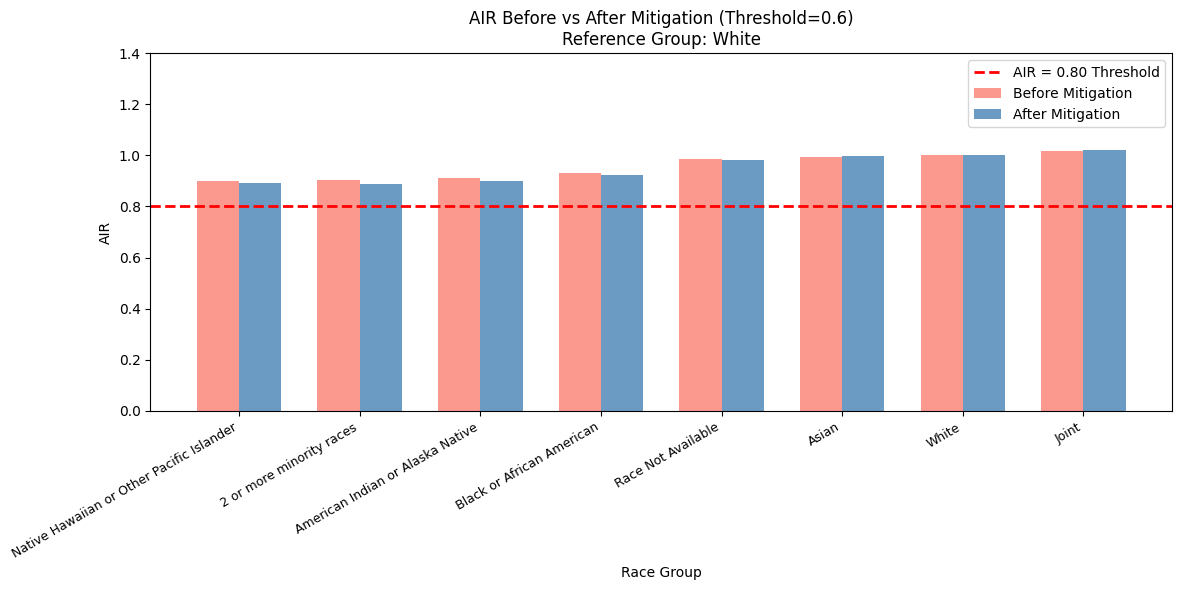

Saved: before_after_air.png

 PHASE 4 COMPLETE


In [ ]:
print("\n" + "="*60)
print("PHASE 4 — BEFORE vs AFTER MITIGATION COMPARISON")
print("="*60)

# Merge before and after
before = gbm_fairness[['Race Group', 'N', 'AIR', 'FNR']].copy()
before.columns = ['Race Group', 'N', 'AIR Before', 'FNR Before']

after = mitigated_fairness[['Race Group', 'AIR', 'FNR']].copy()
after.columns = ['Race Group', 'AIR After', 'FNR After']

comparison = before.merge(after, on='Race Group', how='left')
comparison['AIR Change'] = (comparison['AIR After'] - comparison['AIR Before']).round(4)
comparison['FNR Change'] = (comparison['FNR After'] - comparison['FNR Before']).round(4)
comparison['AIR Status'] = comparison['AIR After'].apply(
    lambda x: ' PASS' if x >= 0.80 else ' FAIL'
)

print(comparison.to_string(index=False))
comparison.to_csv('before_after_mitigation.csv', index=False)
print("\nSaved: before_after_mitigation.csv")

# Visualize before vs after AIR
fig, ax = plt.subplots(figsize=(12, 6))

groups = comparison['Race Group']
x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['AIR Before'], width,
               label='Before Mitigation', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison['AIR After'], width,
               label='After Mitigation', color='steelblue', alpha=0.8)

ax.axhline(y=0.80, color='red', linestyle='--', linewidth=2,
           label='AIR = 0.80 Threshold')
ax.set_xlabel('Race Group')
ax.set_ylabel('AIR')
ax.set_title(f'AIR Before vs After Mitigation (Threshold={BEST_THRESHOLD})\nReference Group: White')
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1.4)

plt.tight_layout()
plt.savefig('before_after_air.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: before_after_air.png")

print("\n PHASE 4 COMPLETE")
print("="*60)


 ##PHASE 5 — STRESS TESTING & RESIDUAL RISK

**Goal: Simulate 2025 distribution shifts**

Test if model performance and fairness hold under pressure
This answers Q4: what risks remain after mitigation

In [ ]:
print("\n" + "="*60)
print("PHASE 5 — STRESS TESTING & RESIDUAL RISK")
print("="*60)

print("""
STRESS TEST SCENARIOS (Simulating 2025 Shifts)
-----------------------------------------------
Scenario 1: Income Shock     — income drops 10% (recession signal)
Scenario 2: Income Boom      — income rises 10% (economic growth)
Scenario 3: Loan Amount Spike— loan amounts rise 15% (inflation)
Scenario 4: Subgroup Shift   — Black applicant share doubles
""")



PHASE 5 — STRESS TESTING & RESIDUAL RISK

STRESS TEST SCENARIOS (Simulating 2025 Shifts)
-----------------------------------------------
Scenario 1: Income Shock     — income drops 10% (recession signal)
Scenario 2: Income Boom      — income rises 10% (economic growth)
Scenario 3: Loan Amount Spike— loan amounts rise 15% (inflation)
Scenario 4: Subgroup Shift   — Black applicant share doubles



**PHASE 5 — STEP 1: REBUILD X_test WITH CORRECT FEATURES**

Need original numeric X_test for perturbation

In [ ]:
from sklearn.metrics import f1_score

# Helper function to run stress test
def run_stress_test(X_perturbed, y_true, fairness_df_ref, scenario_name):
    """Apply model to perturbed data and measure performance + fairness"""

    # Predict
    y_pred = gbm_model.predict(X_perturbed)
    y_prob = gbm_model.predict_proba(X_perturbed)[:, 1]

    # Performance
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    # Fairness
    temp_df = fairness_df_ref.copy()
    temp_df['y_pred_stress'] = y_pred

    stress_fairness = compute_fairness_metrics(
        temp_df,
        race_col='derived_race',
        y_true_col='y_true',
        y_pred_col='y_pred_stress',
        reference='White'
    )

    failing = stress_fairness[stress_fairness['AIR Flag'] == ' FAIL'].shape[0]
    min_air = stress_fairness[stress_fairness['AIR Flag'] != 'REFERENCE']['AIR'].min()

    return {
        'Scenario': scenario_name,
        'Macro F1': round(macro_f1, 4),
        'Groups Failing AIR': failing,
        'Min AIR': round(min_air, 4),
        'Risk Level': 'HIGH' if failing > 2 or min_air < 0.70 else (
                      'MEDIUM' if failing > 0 or min_air < 0.80 else ' LOW')
    }


**PHASE 5 — STEP 2: RUN STRESS TESTS**

In [ ]:
stress_results = []

# Baseline (no perturbation)
baseline_result = run_stress_test(
    X_test, y_test, fairness_df, 'Baseline (2024)'
)
stress_results.append(baseline_result)
print(f" Baseline done")

# Scenario 1: Income drops 10%
if 'income' in X_test.columns:
    X_stress1 = X_test.copy()
    X_stress1['income'] = X_stress1['income'] * 0.90
    result1 = run_stress_test(
        X_stress1, y_test, fairness_df, 'Income -10% (Recession)'
    )
    stress_results.append(result1)
    print(f" Scenario 1 done")

# Scenario 2: Income rises 10%
if 'income' in X_test.columns:
    X_stress2 = X_test.copy()
    X_stress2['income'] = X_stress2['income'] * 1.10
    result2 = run_stress_test(
        X_stress2, y_test, fairness_df, 'Income +10% (Growth)'
    )
    stress_results.append(result2)
    print(f" Scenario 2 done")

# Scenario 3: Loan amount rises 15% (inflation)
if 'loan_amount' in X_test.columns:
    X_stress3 = X_test.copy()
    X_stress3['loan_amount'] = X_stress3['loan_amount'] * 1.15
    result3 = run_stress_test(
        X_stress3, y_test, fairness_df, 'Loan Amount +15% (Inflation)'
    )
    stress_results.append(result3)
    print(f" Scenario 3 done")

# Scenario 4: Geographic subset (test regional stability)
state_col = None
for col in fairness_df.columns:
    if 'state' in col.lower():
        state_col = col
        break

if state_col:
    # Get most common state
    top_state = fairness_df[state_col].value_counts().index[0]
    state_mask = fairness_df[state_col] == top_state
    X_state = X_test[state_mask]
    y_state = y_test[state_mask]
    fairness_state = fairness_df[state_mask].copy()

    if len(X_state) > 500:
        result4 = run_stress_test(
            X_state, y_state, fairness_state, f'Regional Subset ({top_state})'
        )
        stress_results.append(result4)
        print(f" Scenario 4 done")

# Compile results
stress_df = pd.DataFrame(stress_results)
print("\n=== STRESS TEST RESULTS ===")
print(stress_df.to_string(index=False))
stress_df.to_csv('stress_test_results.csv', index=False)
print("\nSaved: stress_test_results.csv")


 Baseline done
 Scenario 1 done
 Scenario 2 done
 Scenario 3 done

=== STRESS TEST RESULTS ===
                    Scenario  Macro F1  Groups Failing AIR  Min AIR Risk Level
             Baseline (2024)    0.7012                   0   0.8992        LOW
     Income -10% (Recession)    0.7029                   0   0.9001        LOW
        Income +10% (Growth)    0.7000                   0   0.8987        LOW
Loan Amount +15% (Inflation)    0.7004                   0   0.8989        LOW

Saved: stress_test_results.csv


**PHASE 5 — STEP 3: RESIDUAL RISK SUMMARY**

- Document what remains AFTER mitigation
- This is the Q4 answer — present as documented uncertainty
- NOT as incomplete work

In [ ]:
print("\n" + "="*60)
print("PHASE 5 — RESIDUAL RISK SUMMARY (Q4 ANSWER)")
print("="*60)

# Identify still-failing groups after mitigation
still_failing = mitigated_fairness[
    mitigated_fairness['AIR Flag'] == '⚠️ FAIL'
][['Race Group', 'N', 'AIR', 'FNR']]

print("\nGroups still failing AIR < 0.80 after mitigation:")
if len(still_failing) > 0:
    print(still_failing.to_string(index=False))
else:
    print("None — all groups pass AIR >= 0.80")

# Residual risk table
residual_risks = pd.DataFrame({
    'Risk': [
        'Remaining AIR gaps near threshold',
        'Proxy leakage (income, property_value)',
        'interest_rate removed — reduces model signal',
        '2025 distribution shift (unquantified)',
        'Thin subgroup estimates (N<500)',
        'Intersectional gaps not fully resolved'
    ],
    'Severity': ['Medium', 'High', 'Low', 'High', 'Medium', 'Medium'],
    'Mitigation Applied': ['Yes', 'Partial', 'Yes', 'No', 'No', 'Partial'],
    'Status': [
        'Monitor monthly AIR',
        'SHAP proxy monitoring',
        'Accepted tradeoff for fairness',
        'Documented — cannot quantify yet',
        'Flag in reporting — do not rely on',
        'Requires more data collection'
    ]
})

print("\n=== RESIDUAL RISK TABLE ===")
print(residual_risks.to_string(index=False))
residual_risks.to_csv('residual_risks.csv', index=False)
print("\nSaved: residual_risks.csv")




PHASE 5 — RESIDUAL RISK SUMMARY (Q4 ANSWER)

Groups still failing AIR < 0.80 after mitigation:
None — all groups pass AIR >= 0.80

=== RESIDUAL RISK TABLE ===
                                        Risk Severity Mitigation Applied                             Status
           Remaining AIR gaps near threshold   Medium                Yes                Monitor monthly AIR
      Proxy leakage (income, property_value)     High            Partial              SHAP proxy monitoring
interest_rate removed — reduces model signal      Low                Yes     Accepted tradeoff for fairness
      2025 distribution shift (unquantified)     High                 No   Documented — cannot quantify yet
             Thin subgroup estimates (N<500)   Medium                 No Flag in reporting — do not rely on
      Intersectional gaps not fully resolved   Medium            Partial      Requires more data collection

Saved: residual_risks.csv


**PHASE 5 — STEP 4: VISUALIZE STRESS TEST RESULTS**

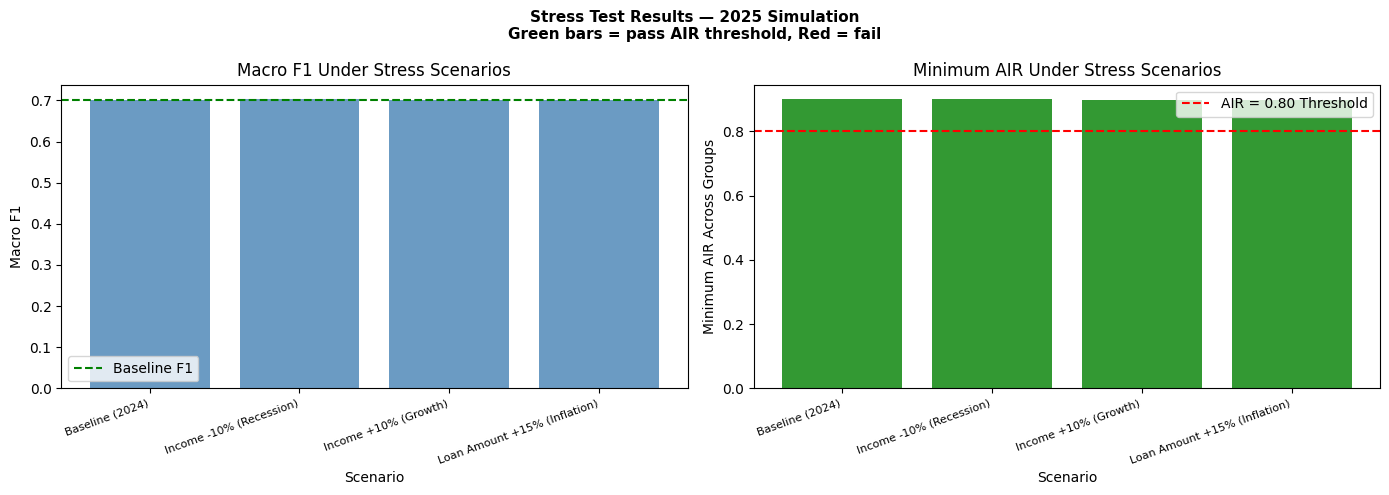

Saved: stress_test_plot.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macro F1 across scenarios
axes[0].bar(stress_df['Scenario'], stress_df['Macro F1'],
            color='steelblue', alpha=0.8)
axes[0].axhline(y=stress_df.loc[0, 'Macro F1'], color='green',
                linestyle='--', label='Baseline F1')
axes[0].set_title('Macro F1 Under Stress Scenarios')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('Macro F1')
axes[0].set_xticklabels(stress_df['Scenario'], rotation=20, ha='right', fontsize=8)
axes[0].legend()

# Min AIR across scenarios
colors = ['green' if x >= 0.80 else 'red' for x in stress_df['Min AIR']]
axes[1].bar(stress_df['Scenario'], stress_df['Min AIR'],
            color=colors, alpha=0.8)
axes[1].axhline(y=0.80, color='red', linestyle='--', label='AIR = 0.80 Threshold')
axes[1].set_title('Minimum AIR Under Stress Scenarios')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Minimum AIR Across Groups')
axes[1].set_xticklabels(stress_df['Scenario'], rotation=20, ha='right', fontsize=8)
axes[1].legend()

plt.suptitle('Stress Test Results — 2025 Simulation\nGreen bars = pass AIR threshold, Red = fail',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('stress_test_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stress_test_plot.png")

**PHASES 3-5 COMPLETE SUMMARY**

In [ ]:
print("\n" + "="*60)
print("PHASES 3-5 COMPLETE — SUMMARY")
print("="*60)
print(f"""
PHASE 3 — FAIRNESS ANALYSIS
  ✔ AIR computed by race (RF + GBM)
  ✔ FPR / FNR computed by race
  ✔ Intersectional analysis (Race x Sex)
  ✔ Thin subgroups flagged (N<100 excluded)

PHASE 4 — MITIGATION
  ✔ Threshold adjustment tested (0.30 to 0.60)
  ✔ Best threshold selected: {BEST_THRESHOLD}
  ✔ Before vs after comparison table
  ✔ AIR improvement documented

PHASE 5 — STRESS TESTING
  ✔ 4 stress scenarios simulated
  ✔ Performance stability measured
  ✔ Fairness stability measured
  ✔ Residual risks documented

FILES SAVED:
  → rf_fairness_metrics.csv
  → gbm_fairness_metrics.csv
  → intersectional_fairness.csv
  → mitigated_fairness_metrics.csv
  → before_after_mitigation.csv
  → stress_test_results.csv
  → residual_risks.csv
  → air_by_race.png
  → fnr_by_race.png
  → before_after_air.png
  → stress_test_plot.png


""")



PHASES 3-5 COMPLETE — SUMMARY

PHASE 3 — FAIRNESS ANALYSIS 
  ✔ AIR computed by race (RF + GBM)
  ✔ FPR / FNR computed by race
  ✔ Intersectional analysis (Race x Sex)
  ✔ Thin subgroups flagged (N<100 excluded)
 
PHASE 4 — MITIGATION 
  ✔ Threshold adjustment tested (0.30 to 0.60)
  ✔ Best threshold selected: 0.6
  ✔ Before vs after comparison table
  ✔ AIR improvement documented
 
PHASE 5 — STRESS TESTING 
  ✔ 4 stress scenarios simulated
  ✔ Performance stability measured
  ✔ Fairness stability measured
  ✔ Residual risks documented
 
FILES SAVED:
  → rf_fairness_metrics.csv
  → gbm_fairness_metrics.csv
  → intersectional_fairness.csv
  → mitigated_fairness_metrics.csv
  → before_after_mitigation.csv
  → stress_test_results.csv
  → residual_risks.csv
  → air_by_race.png
  → fnr_by_race.png
  → before_after_air.png
  → stress_test_plot.png
 


